# 卷积神经网络

## 下载数据（手写数字）

In [1]:
import torch
from torchvision import datasets, transforms

In [ ]:
# 加载完整数据集（download=True会自动下载）
# 最简单的 transform：只转成张量，不做标准化
# transform = transforms.ToTensor()

# # 或者直接写在参数里
# full_train = datasets.MNIST(
#     root='./data', 
#     train=True, 
#     download=True, 
#     transform=transforms.ToTensor()   # 直接写，不需要提前定义变量
# )

## 手写数字识别

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# ========== 1. 检查设备 ==========
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device} (CPU模式)")

使用设备: cpu (CPU模式)


In [5]:
# ========== 2. 加载数据集（使用已下载的数据） ==========
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 加载完整数据集（download=False 使用已下载的）
full_train = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
full_test = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

In [6]:
# ✅ 关键：只取子集，加快训练速度
train_dataset = Subset(full_train, range(3000))   # 只用 3000 张训练
test_dataset = Subset(full_test, range(500))      # 只用 500 张测试

# 创建数据加载器
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集大小: {len(train_dataset)} 张")
print(f"测试集大小: {len(test_dataset)} 张")

训练集大小: 3000 张
测试集大小: 500 张


In [10]:
# ========== 3. 定义轻量级 CNN ==========
class LightCNN(nn.Module):
    """
    轻量级 CNN，专为 CPU 设计
    参数量: 约 10 万
    """
    def __init__(self):
        super().__init__()
        # 卷积块1: 1 → 16 通道
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)  # 28x28 → 14x14
        
        # 卷积块2: 16 → 32 通道
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)  # 14x14 → 7x7
        
        # 全连接层
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)  # 展平
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x

model = LightCNN().to(device)
print(f"\n模型参数量: {sum(p.numel() for p in model.parameters()):,}")


# ========== 4. 定义损失函数和优化器 ==========
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


模型参数量: 105,866


In [11]:
# ========== 5. 训练函数 ==========
def train_one_epoch():
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(train_loader), 100. * correct / total

# ========== 6. 测试函数 ==========
def test():
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return 100. * correct / total

In [12]:
# ========== 7. 开始训练 ==========
print("\n" + "=" * 50)
print("开始训练（CPU 模式，约 1-2 分钟）")
print("=" * 50)

epochs = 5
train_losses = []
train_accs = []
test_accs = []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch()
    test_acc = test()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(f"Epoch {epoch}/{epochs} | "
          f"损失: {train_loss:.4f} | "
          f"训练准确率: {train_acc:.2f}% | "
          f"测试准确率: {test_acc:.2f}%")


开始训练（CPU 模式，约 1-2 分钟）
Epoch 1/5 | 损失: 1.3826 | 训练准确率: 56.53% | 测试准确率: 82.60%
Epoch 2/5 | 损失: 0.5658 | 训练准确率: 82.83% | 测试准确率: 90.40%
Epoch 3/5 | 损失: 0.3840 | 训练准确率: 88.50% | 测试准确率: 93.80%
Epoch 4/5 | 损失: 0.2760 | 训练准确率: 91.67% | 测试准确率: 95.20%
Epoch 5/5 | 损失: 0.2299 | 训练准确率: 93.60% | 测试准确率: 95.60%


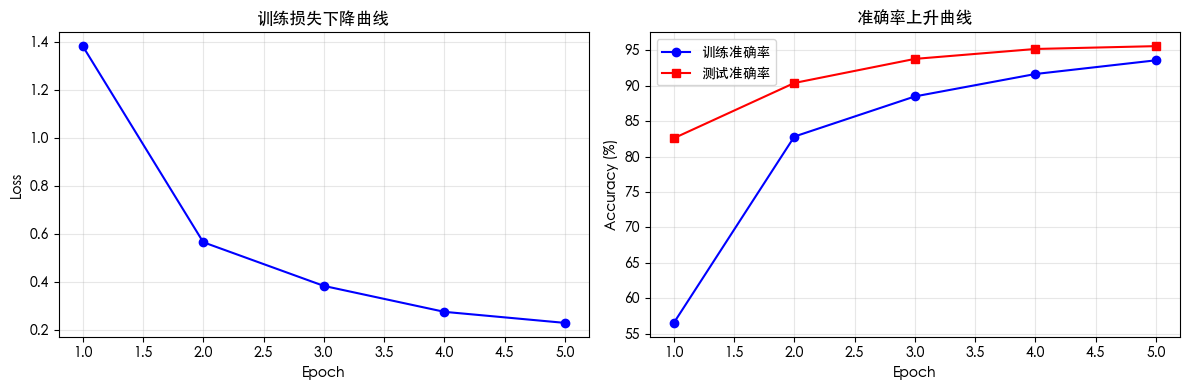

In [13]:
# ========== 8. 可视化训练过程 ==========
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(range(1, epochs+1), train_losses, 'o-', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('训练损失下降曲线')
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(range(1, epochs+1), train_accs, 'o-', label='训练准确率', color='blue')
axes[1].plot(range(1, epochs+1), test_accs, 's-', label='测试准确率', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('准确率上升曲线')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

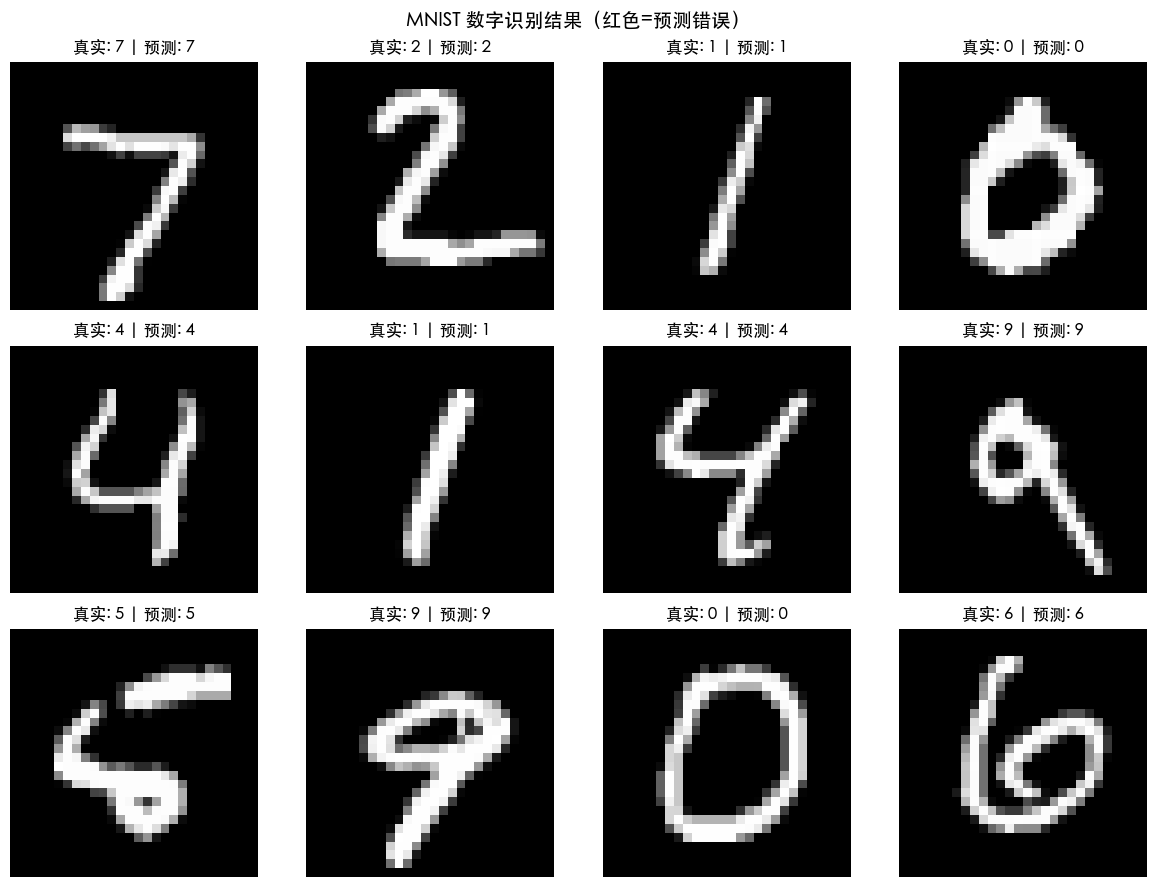


📊 训练总结
✅ 训练集: 3000 张
✅ 测试集: 500 张
✅ 最终测试准确率: 95.60%
✅ 模型参数量: 105,866


In [14]:
# ========== 9. 展示预测结果 ==========
def show_predictions(num_images=12):
    model.eval()
    
    # 获取一批测试数据
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels
    
    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)
    
    # 绘图
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.flatten()
    
    for i in range(num_images):
        img = images[i].cpu().squeeze().numpy()
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'真实: {labels[i].item()} | 预测: {preds[i].item()}')
        axes[i].axis('off')
        
        # 预测错误用红色标注
        if labels[i].item() != preds[i].item():
            axes[i].set_title(f'真实: {labels[i].item()} | 预测: {preds[i].item()}', color='red')
    
    plt.suptitle('MNIST 数字识别结果（红色=预测错误）', fontsize=14)
    plt.tight_layout()
    plt.show()

show_predictions()

# ========== 10. 总结 ==========
print("\n" + "=" * 50)
print("📊 训练总结")
print("=" * 50)
print(f"✅ 训练集: 3000 张")
print(f"✅ 测试集: 500 张")
print(f"✅ 最终测试准确率: {test_accs[-1]:.2f}%")
print(f"✅ 模型参数量: {sum(p.numel() for p in model.parameters()):,}")